# Task 9: Business Insights & Executive Report – E-Commerce Cohort Analysis

## Objective
Analyze customer retention using cohort analysis and identify key business insights from the Brazilian E-Commerce dataset.

## Executive Summary

- Customer retention from 2017 to 2018 was very low at **1.56%**.
- Only **681 out of 43,708** customers acquired in 2017 made another purchase in 2018.
- Delivery time showed a **moderate negative correlation (-0.466)** with review scores, indicating that longer delivery times tend to be associated with lower customer satisfaction.
- The top **1% of customers (954 Power Users)** generated revenue ranging from approximately **1,014.60 to 13,440.00**.
- These findings suggest that improving customer retention, delivery performance, and loyalty programs for high-value customers could provide significant business value.

In [26]:
import os

os.listdir()

['.venv',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv',
 'task9_cohort_analysis.ipynb']

In [27]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Payments:", payments.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Payments: (103886, 5)


In [28]:
print("CUSTOMERS COLUMNS:")
print(customers.columns.tolist())

print("\nORDERS COLUMNS:")
print(orders.columns.tolist())

print("\nPAYMENTS COLUMNS:")
print(payments.columns.tolist())

CUSTOMERS COLUMNS:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDERS COLUMNS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

PAYMENTS COLUMNS:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [29]:
cohort_data = orders[
    ["order_id", "customer_id", "order_purchase_timestamp"]
].merge(
    customers[
        ["customer_id", "customer_unique_id"]
    ],
    on="customer_id",
    how="left"
)

print(cohort_data.head())
print("\nShape:", cohort_data.shape)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_purchase_timestamp                customer_unique_id  
0      2017-10-02 10:56:33  7c396fd4830fd04220f754e42b4e5bff  
1      2018-07-24 20:41:37  af07308b275d755c9edb36a90c618231  
2      2018-08-08 08:38:49  3a653a41f6f9fc3d2a113cf8398680e8  
3      2017-11-18 19:28:06  7c142cf63193a1473d2e66489a9ae977  
4      2018-02-13 21:18:39  72632f0f9dd73dfee390c9b22eb56dd6  

Shape: (99441, 4)


In [30]:
cohort_data["order_purchase_timestamp"] = pd.to_datetime(
    cohort_data["order_purchase_timestamp"]
)

cohort_data["purchase_month"] = (
    cohort_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

first_purchase = (
    cohort_data.groupby("customer_unique_id")["purchase_month"]
    .min()
    .reset_index()
    .rename(columns={"purchase_month": "cohort_month"})
)

print(first_purchase.head())
print("\nNumber of unique customers:", len(first_purchase))

                 customer_unique_id cohort_month
0  0000366f3b9a7992bf8c76cfdf3221e2      2018-05
1  0000b849f77a49e4a4ce2b2a4ca5be3f      2018-05
2  0000f46a3911fa3c0805444483337064      2017-03
3  0000f6ccb0745a6a4b88665a16c9f078      2017-10
4  0004aac84e0df4da2b147fca70cf8255      2017-11

Number of unique customers: 96096


In [31]:
cohort_data = cohort_data.merge(
    first_purchase,
    on="customer_unique_id",
    how="left"
)

cohort_data["cohort_index"] = (
    (cohort_data["purchase_month"].dt.year - cohort_data["cohort_month"].dt.year) * 12
    + (cohort_data["purchase_month"].dt.month - cohort_data["cohort_month"].dt.month)
)

print(
    cohort_data[
        ["customer_unique_id", "purchase_month", "cohort_month", "cohort_index"]
    ].head(10)
)

                 customer_unique_id purchase_month cohort_month  cohort_index
0  7c396fd4830fd04220f754e42b4e5bff        2017-10      2017-09             1
1  af07308b275d755c9edb36a90c618231        2018-07      2018-07             0
2  3a653a41f6f9fc3d2a113cf8398680e8        2018-08      2018-08             0
3  7c142cf63193a1473d2e66489a9ae977        2017-11      2017-11             0
4  72632f0f9dd73dfee390c9b22eb56dd6        2018-02      2018-02             0
5  80bb27c7c16e8f973207a5086ab329e2        2017-07      2017-07             0
6  36edbb3fb164b1f16485364b6fb04c73        2017-04      2017-04             0
7  932afa1e708222e5821dac9cd5db4cae        2017-05      2017-05             0
8  39382392765b6dc74812866ee5ee92a7        2017-01      2017-01             0
9  299905e3934e9e181bfb2e164dd4b4f8        2017-07      2017-07             0


In [32]:
cohort_counts = (
    cohort_data
    .groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

print(cohort_counts.head(15))

   cohort_month  cohort_index  customer_unique_id
0       2016-09             0                   4
1       2016-10             0                 321
2       2016-10             6                   1
3       2016-10             9                   1
4       2016-10            11                   1
5       2016-10            13                   1
6       2016-10            15                   1
7       2016-10            17                   1
8       2016-10            19                   2
9       2016-10            20                   2
10      2016-12             0                   1
11      2016-12             1                   1
12      2017-01             0                 764
13      2017-01             1                   3
14      2017-01             2                   2


In [33]:
cohort_pivot = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

retention = cohort_pivot.divide(
    cohort_pivot[0],
    axis=0
) * 100

retention = retention.round(2)

print(retention.head(10))

cohort_index     0       1     2     3     4     5     6     7     8     9   \
cohort_month                                                                  
2016-09       100.0     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2016-10       100.0     NaN   NaN   NaN   NaN   NaN  0.31   NaN   NaN  0.31   
2016-12       100.0  100.00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2017-01       100.0    0.39  0.26  0.13  0.39  0.13  0.52  0.13  0.13   NaN   
2017-02       100.0    0.23  0.29  0.11  0.40  0.11  0.23  0.17  0.17  0.23   
2017-03       100.0    0.49  0.38  0.38  0.34  0.15  0.15  0.30  0.34  0.08   
2017-04       100.0    0.60  0.21  0.17  0.34  0.26  0.34  0.30  0.30  0.17   
2017-05       100.0    0.50  0.50  0.39  0.31  0.33  0.42  0.17  0.25  0.31   
2017-06       100.0    0.48  0.35  0.41  0.25  0.38  0.38  0.22  0.13  0.22   
2017-07       100.0    0.51  0.36  0.26  0.28  0.21  0.31  0.10  0.18  0.26   

cohort_index    10    11    12    13    14    15   

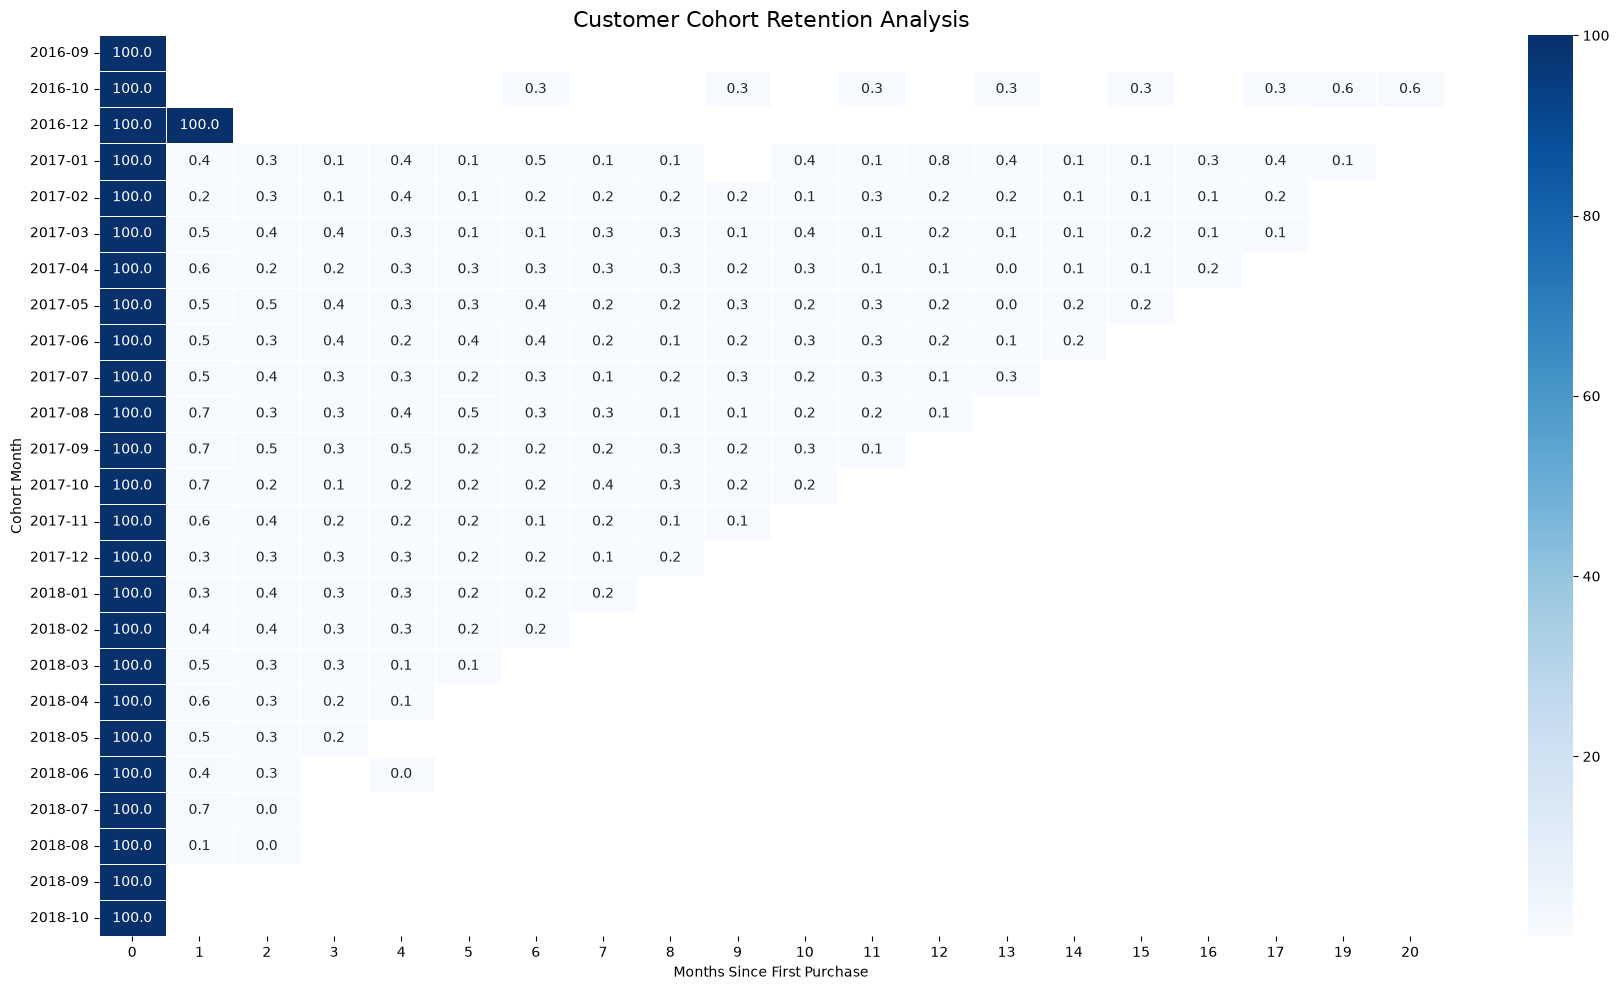

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Customer Cohort Retention Analysis", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()

plt.show()

In [35]:
retention_2017 = retention.loc[
    retention.index.astype(str).str.startswith("2017")
]

print(retention_2017)

cohort_index     0     1     2     3     4     5     6     7     8     9   \
cohort_month                                                                
2017-01       100.0  0.39  0.26  0.13  0.39  0.13  0.52  0.13  0.13   NaN   
2017-02       100.0  0.23  0.29  0.11  0.40  0.11  0.23  0.17  0.17  0.23   
2017-03       100.0  0.49  0.38  0.38  0.34  0.15  0.15  0.30  0.34  0.08   
2017-04       100.0  0.60  0.21  0.17  0.34  0.26  0.34  0.30  0.30  0.17   
2017-05       100.0  0.50  0.50  0.39  0.31  0.33  0.42  0.17  0.25  0.31   
2017-06       100.0  0.48  0.35  0.41  0.25  0.38  0.38  0.22  0.13  0.22   
2017-07       100.0  0.51  0.36  0.26  0.28  0.21  0.31  0.10  0.18  0.26   
2017-08       100.0  0.69  0.33  0.26  0.36  0.53  0.29  0.26  0.14  0.14   
2017-09       100.0  0.68  0.53  0.29  0.46  0.22  0.22  0.24  0.29  0.17   
2017-10       100.0  0.69  0.25  0.09  0.22  0.20  0.22  0.36  0.27  0.20   
2017-11       100.0  0.55  0.38  0.18  0.19  0.18  0.11  0.19  0.14  0.05   

In [36]:
retention_2017_to_2018 = retention_2017[
    [col for col in retention_2017.columns if col >= 1]
]

print("2017 Cohorts Retention into Subsequent Months:")
print(retention_2017_to_2018.iloc[:, :5])

2017 Cohorts Retention into Subsequent Months:
cohort_index     1     2     3     4     5
cohort_month                              
2017-01       0.39  0.26  0.13  0.39  0.13
2017-02       0.23  0.29  0.11  0.40  0.11
2017-03       0.49  0.38  0.38  0.34  0.15
2017-04       0.60  0.21  0.17  0.34  0.26
2017-05       0.50  0.50  0.39  0.31  0.33
2017-06       0.48  0.35  0.41  0.25  0.38
2017-07       0.51  0.36  0.26  0.28  0.21
2017-08       0.69  0.33  0.26  0.36  0.53
2017-09       0.68  0.53  0.29  0.46  0.22
2017-10       0.69  0.25  0.09  0.22  0.20
2017-11       0.55  0.38  0.18  0.19  0.18
2017-12       0.26  0.27  0.35  0.27  0.20


In [37]:
# Customers whose first purchase was in 2017
customers_2017 = first_purchase[
    first_purchase["cohort_month"].dt.year == 2017
]

# Their orders
orders_2017 = cohort_data[
    cohort_data["customer_unique_id"].isin(
        customers_2017["customer_unique_id"]
    )
]

# Orders made during 2018
orders_2018 = orders_2017[
    orders_2017["purchase_month"].dt.year == 2018
]

# Unique 2017 customers who purchased again in 2018
returned_customers_2018 = orders_2018["customer_unique_id"].nunique()

total_customers_2017 = customers_2017["customer_unique_id"].nunique()

retention_2017_2018 = (
    returned_customers_2018 / total_customers_2017
) * 100

print("2017 customers:", total_customers_2017)
print("2017 customers who purchased again in 2018:", returned_customers_2018)
print(f"2017 → 2018 retention: {retention_2017_2018:.2f}%")

2017 customers: 43708
2017 customers who purchased again in 2018: 681
2017 → 2018 retention: 1.56%


In [38]:
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

print("Reviews:", reviews.shape)
print(reviews.columns.tolist())

Reviews: (99224, 7)
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [39]:
customers_raw = pd.read_csv("olist_customers_dataset.csv")

print(customers_raw.columns.tolist())

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [40]:
delivery_data = orders[
    ["order_id", "customer_id", "order_purchase_timestamp", "order_delivered_customer_date"]
].merge(
    customers_raw[
        ["customer_id", "customer_state"]
    ],
    on="customer_id",
    how="left"
).merge(
    reviews[
        ["order_id", "review_score"]
    ],
    on="order_id",
    how="left"
)

delivery_data["order_purchase_timestamp"] = pd.to_datetime(
    delivery_data["order_purchase_timestamp"]
)

delivery_data["order_delivered_customer_date"] = pd.to_datetime(
    delivery_data["order_delivered_customer_date"]
)

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

print(delivery_data.head())
print("\nShape:", delivery_data.shape)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_purchase_timestamp order_delivered_customer_date customer_state  \
0      2017-10-02 10:56:33           2017-10-10 21:25:13             SP   
1      2018-07-24 20:41:37           2018-08-07 15:27:45             BA   
2      2018-08-08 08:38:49           2018-08-17 18:06:29             GO   
3      2017-11-18 19:28:06           2017-12-02 00:28:42             RN   
4      2018-02-13 21:18:39           2018-02-16 18:17:02             SP   

   review_score  delivery_days  
0           4.0            8.0  
1           4.0           13.0  
2          

In [41]:
state_analysis = (
    delivery_data
    .dropna(subset=["delivery_days", "review_score"])
    .groupby("customer_state")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        average_review_score=("review_score", "mean"),
        number_of_orders=("order_id", "nunique")
    )
    .round(2)
    .sort_values("average_delivery_days", ascending=False)
)

print(state_analysis)

                average_delivery_days  average_review_score  number_of_orders
customer_state                                                               
RR                              28.98                  3.90                41
AP                              26.67                  4.24                66
AM                              25.88                  4.22               144
AL                              23.95                  3.84               394
PA                              23.19                  3.91               933
SE                              20.95                  3.91               334
MA                              20.94                  3.84               712
CE                              20.76                  3.94              1273
AC                              20.64                  4.09                80
PB                              19.75                  4.08               512
PI                              19.03                  4.00     

In [42]:
correlation = state_analysis[
    ["average_delivery_days", "average_review_score"]
].corr()

print(correlation)

                       average_delivery_days  average_review_score
average_delivery_days               1.000000             -0.466216
average_review_score               -0.466216              1.000000


In [43]:
order_items = pd.read_csv("olist_order_items_dataset.csv")

print(order_items.shape)
print(order_items.columns.tolist())

(112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [44]:
power_users_data = order_items[
    ["order_id", "price"]
].merge(
    orders[
        ["order_id", "customer_id"]
    ],
    on="order_id",
    how="left"
).merge(
    customers_raw[
        ["customer_id", "customer_unique_id"]
    ],
    on="customer_id",
    how="left"
)

customer_revenue = (
    power_users_data
    .groupby("customer_unique_id")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "revenue"})
    .sort_values("revenue", ascending=False)
)

print(customer_revenue.head(10))
print("\nTotal customers:", len(customer_revenue))

                     customer_unique_id  revenue
3799   0a0a92112bd4c708ca5fde585afaa872  13440.0
81388  da122df9eeddfedc1dc1f5349a1a690c   7388.0
44139  763c8b1c9c68a0229c42c9fc6f662b93   7160.0
82230  dc4802a71eae9be1dd28f5d788ceb526   6735.0
26015  459bef486812aa25204be022145caa62   6729.0
95131  ff4159b92c40ebe40454e3e6a7c35ed6   6499.0
23947  4007669dec559734d6f53e029e360987   5934.6
89056  eebb5dda148d3893cdaf5b5ca3040ccb   4690.0
34820  5d0a2980b292d049061542014e8960bf   4599.9
27242  48e1ac109decbb87765a3eade6854098   4590.0

Total customers: 95420


In [45]:
top_1_percent_count = int(len(customer_revenue) * 0.01)

power_users = customer_revenue.head(top_1_percent_count)

print("Top 1% customers:", top_1_percent_count)
print("\nPower Users:")
print(power_users.head(10))

print("\nMinimum revenue among Power Users:", power_users["revenue"].min())
print("Maximum revenue:", power_users["revenue"].max())

Top 1% customers: 954

Power Users:
                     customer_unique_id  revenue
3799   0a0a92112bd4c708ca5fde585afaa872  13440.0
81388  da122df9eeddfedc1dc1f5349a1a690c   7388.0
44139  763c8b1c9c68a0229c42c9fc6f662b93   7160.0
82230  dc4802a71eae9be1dd28f5d788ceb526   6735.0
26015  459bef486812aa25204be022145caa62   6729.0
95131  ff4159b92c40ebe40454e3e6a7c35ed6   6499.0
23947  4007669dec559734d6f53e029e360987   5934.6
89056  eebb5dda148d3893cdaf5b5ca3040ccb   4690.0
34820  5d0a2980b292d049061542014e8960bf   4599.9
27242  48e1ac109decbb87765a3eade6854098   4590.0

Minimum revenue among Power Users: 1014.5999999999999
Maximum revenue: 13440.0


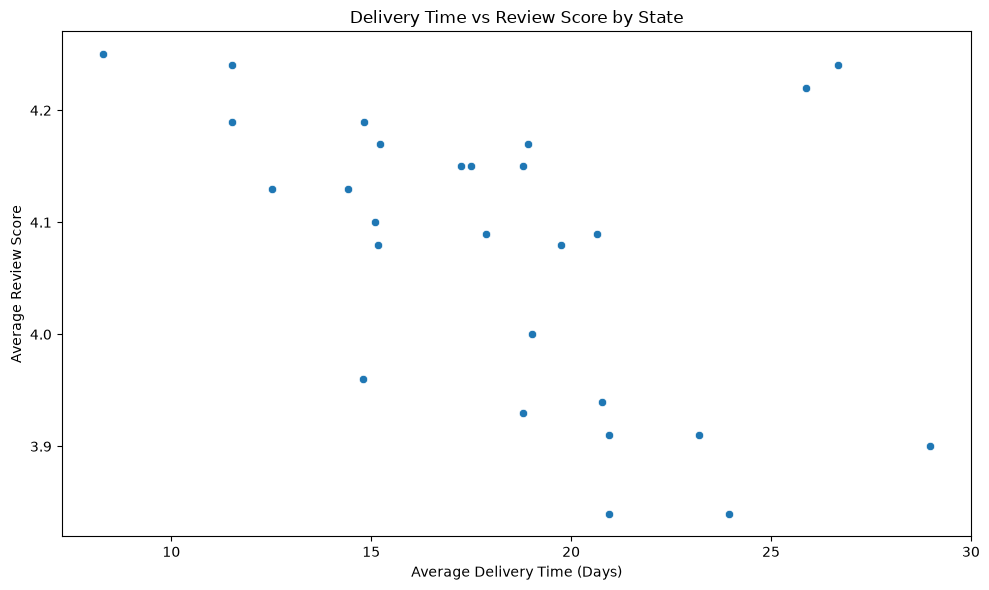

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=state_analysis,
    x="average_delivery_days",
    y="average_review_score"
)

plt.title("Delivery Time vs Review Score by State")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Average Review Score")
plt.tight_layout()

plt.show()

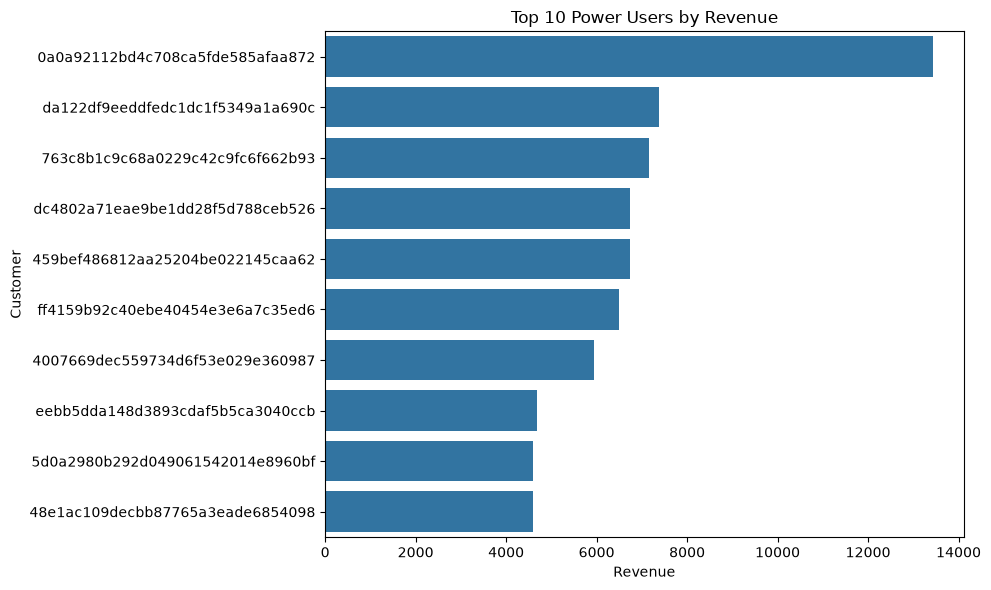

In [47]:
top_power_users = power_users.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_power_users,
    x="revenue",
    y="customer_unique_id"
)

plt.title("Top 10 Power Users by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")
plt.tight_layout()

plt.show()